In [39]:
using CollectiveSpins
using PyPlot
using ProgressMeter
using Statistics

In [40]:
""" Prepare the initial state of the system 
with a phase correlation imposed between the atoms
because the laser arrive on the lattice with an angle θl """
function prepare_phi_IS(θl, λl, theta_array, system)
    phi_array = zeros(N)
    for i = 1:N
        phi_array[i] = 2pi * sqrt(sum((system.spins[i].position .* [cos(θl), sin(θl), 0]) .^ 2))
    end
    return phi_array
end

prepare_phi_IS

In [41]:
### Define the system
Nx, Ny, Nz = [4, 4, 1]
N = Nx*Ny*Nz
d_xy, d_z = 266., 532. # Optical lattice spacing in nm

λl = 1299.
θl = 30*π/180
Γ0 = 1. # SE decay rate

# Define the system
a_dim,b_dim,c_dim = [d_xy,d_xy,d_z]/λl
geo = CollectiveSpins.geometry.box(a_dim,b_dim,c_dim;Nx=Nx,Ny=Ny,Nz=Nz)

θi = π/2
φi = 1

Tstep, Tend = 1e-3, 1 # Normalised by Γ0
T = [0:Tstep:Tend;];

# Scanning Bext

In [42]:
theta_Bext_array = range(0, pi/2, 10)
phi_Bext_array = range(0, pi/2, 10);

In [43]:
sols = []
max_diff =[]

@showprogress for i = 1:length(theta_Bext_array)
    @showprogress for j = 1:length(phi_Bext_array)
        # Tilted Quantization axis
        e = [sin(theta_Bext_array[i])*cos(phi_Bext_array[j]), sin(theta_Bext_array[i])*sin(phi_Bext_array[j]), cos(theta_Bext_array[i])] 
        system = CollectiveSpins.SpinCollection(geo, e, gammas=1.)

        # Initial state
        theta_array = ones(N)*θi
        phi_array = prepare_phi_IS(θl, λl, theta_array, system)*φi
        Ψ0 = CollectiveSpins.mpc.blochstate(phi_array, theta_array)

        # Computation
        ρt = CollectiveSpins.mpc.timeevolution(T, system, Ψ0, dt=Tstep)[2]
        mean_σz67 = [-1 *(mean(CollectiveSpins.mpc.sz(ρ))+1) /2 - 6 for ρ in ρt]

        # Save
        push!(sols, mean_σz67)
        push!(max_diff, maximum(diff(mean_σz67)/Tstep))
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:02
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:11


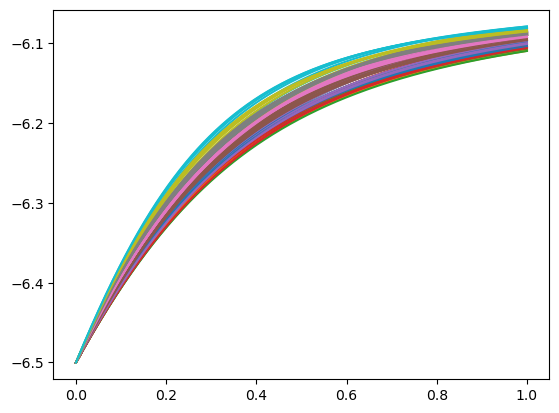

In [44]:
close("all")
figure()
for s in sols
    plot(T, s)
end
gcf()

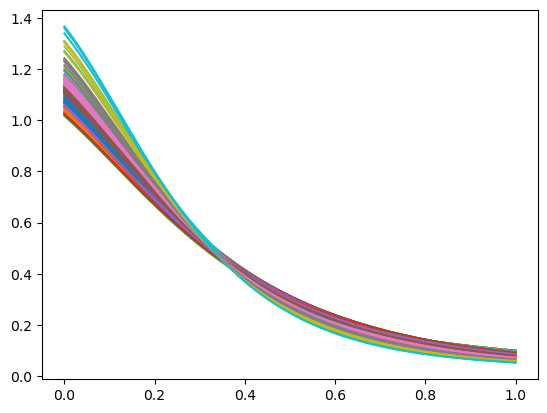

In [45]:
close("all")
figure()
for s in sols
    plot(T[1:end-1], diff(s)./Tstep)
end
pygui(false); gcf()
#pygui(true); show()

In [46]:
mat_max_diff = reshape(max_diff, (length(phi_Bext_array), length(theta_Bext_array)));

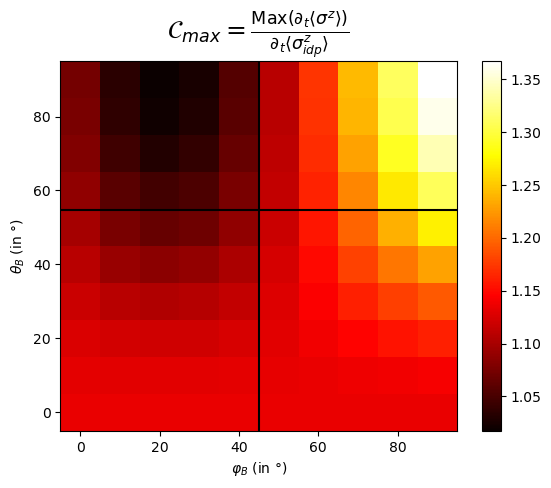

In [47]:
close("all")
fig, ax = plt.subplots()
c = pcolormesh(phi_Bext_array*180/π, theta_Bext_array*180/π, mat_max_diff', cmap="hot")
ylabel(L"$\theta_B$ (in °)")
xlabel(L"$\varphi_B$ (in °)")
fig.colorbar(c, ax=ax)

axhline(54.7, color="black")
axvline(45, color="black")
title(L"\mathcal{C}_{max}=\frac{\text{Max}(\partial_t \langle \sigma^z \rangle)}{\partial_t \langle \sigma^z_{idp} \rangle}", fontsize=18)
#pygui(true); show()
savefig("CmaxVaryBext_ElecDDOnly_Nx_$(Nx)_Ny_$(Ny)_Nz_$(Nz)_theta_$(round(θi, digits=2))_phi_$(φi)_thetal_$(round(θl, digits=2)).pdf")
pygui(false); gcf()

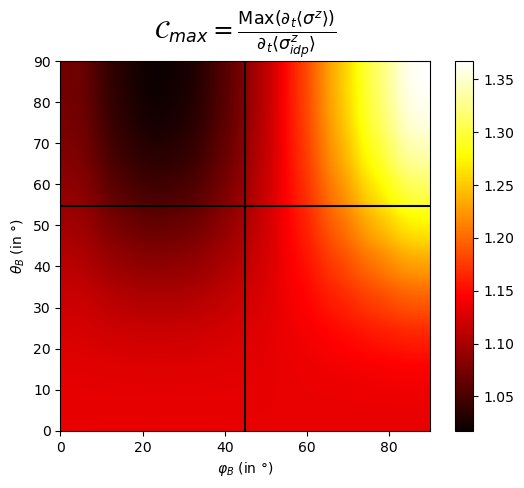

In [48]:
close("all")
fig, ax = plt.subplots()
c = imshow(mat_max_diff', cmap="hot", interpolation="gaussian", extent=(0, 90, 0, 90), aspect=1, origin="lower")
xlabel(L"$\varphi_B$ (in °)")
ylabel(L"$\theta_B$ (in °)")

axhline(54.7, color="black")
axvline(45, color="black")
title(L"\mathcal{C}_{max}=\frac{\text{Max}(\partial_t \langle \sigma^z \rangle)}{\partial_t \langle \sigma^z_{idp} \rangle}", fontsize=18)
fig.colorbar(c, ax=ax)
savefig("SmoothedCmaxVaryBext_ElecDDOnly_Nx_$(Nx)_Ny_$(Ny)_Nz_$(Nz)_theta_$(round(θi, digits=2))_phi_$(φi)_thetal_$(round(θl, digits=2)).pdf")
gcf()